<a href="https://colab.research.google.com/github/cynthianekesa/Misala-App/blob/main/Drontplantenv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Drone Medicinal Plant Identifier - Reinforcement Learning**

This notebook simulates a drone navigating a 2D grid forest. At each cell, the drone can choose to move or use a TensorFlow model to identify a medicinal plant. The reward structure guides the behaviour of the drone.

In [ ]:
pip install gymnasium numpy tensorflow==2.17.0 pillow matplotlib stable_baselines3


In [ ]:
# Mount Google Drive to access datasets
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from matplotlib import patches
from PIL import Image
import tensorflow as tf

class DronePlantEnv(gym.Env):
    def __init__(self, plant_folder='/content/drive/MyDrive/plants', model_path='/content/drive/MyDrive/model1.h5', grid_size=10):
        super(DronePlantEnv, self).__init__()
        self.grid_size = (grid_size, grid_size)
        self.plant_folder = plant_folder
        # Load the model with compile=False to potentially avoid compatibility issues
        with tf.device('/GPU:0'):
           self.model = tf.keras.models.load_model(model_path, compile=False)
        self.class_names = sorted(os.listdir(plant_folder))
        self.action_space = spaces.Discrete(5)  # up, down, left, right, identify

       # Observation is now a normalized rendered image of size 96x96x3
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(96, 96, 3),
            dtype=np.float32
        )

        self.initial_plant_positions = self._generate_plant_positions() # Store initial positions
        self.plant_images = self._load_plant_images()
        self.max_steps = 200
        self.current_step = 0
        self.reset()

    def _generate_plant_positions(self):
        random.seed(42)
        positions = set()
        while len(positions) < 27:
            positions.add((random.randint(0, self.grid_size[0] - 1), random.randint(0, self.grid_size[1] - 1)))
        return dict(zip(self.class_names, list(positions)))

    def _load_plant_images(self):
        images = {}
        for cls in self.class_names:
            folder = os.path.join(self.plant_folder, cls)
            image_files = [f for f in os.listdir(folder) if f.endswith(('jpg', 'png'))]
            if image_files:
                img_path = os.path.join(folder, image_files[0])
                images[cls] = Image.open(img_path).resize((40, 40))
        return images

    def reset(self, seed=None, options=None):
        self.drone_pos = [0, 0]
        self.visited = set()
        self.last_prediction = None
        self.current_step = 0
        self.plant_positions = self.initial_plant_positions.copy() # Reset plants to initial positions
        return self._get_obs(), {}

    def step(self, action):
        x, y = self.drone_pos
        reward = 0
        done = False

        # Movement actions
        if action == 0: # Up
            if y > 0: y -= 1
        elif action == 1: # Down
            if y < self.grid_size[1] - 1: y += 1
        elif action == 2: # Left
            if x > 0: x -= 1
        elif action == 3: # Right
            if x < self.grid_size[0] - 1: x += 1
        elif action == 4: # Identify
            self.last_prediction = self._identify_plant(x, y)
            if self.last_prediction:
                pred_cls, confidence = self.last_prediction
                actual_cls = None
                plant_key_to_remove = None
                for cls, pos in self.plant_positions.items():
                    if list(pos) == [x, y]:
                        actual_cls = cls
                        plant_key_to_remove = cls
                        break
                if actual_cls:
                    if pred_cls == actual_cls:
                        # Increased reward for correct identification with confidence bonus
                        reward += 50 + (confidence * 40)
                        if plant_key_to_remove:
                            del self.plant_positions[plant_key_to_remove] # Remove plant
                            reward += 20 # Additional reward for successful removal
                    else:
                        # Penalty for incorrect identification
                        reward -= 10
                else:
                    # Penalty for identifying when no plant is present
                    reward -= 5

        self.drone_pos = [x, y]
        new_pos = tuple(self.drone_pos)

        # Exploration reward/penalty
        if new_pos not in self.visited:
            reward += 1 # Reward for visiting new cells
            self.visited.add(new_pos)
        else:
            reward -= 0.7 # Small penalty for revisiting

        self.current_step += 1

        # Add small step penalty to discourage wasting steps
        reward -= 0.01

        # Check for episode termination
        if self.current_step >= self.max_steps or not self.plant_positions:
            done = True
            if not self.plant_positions:
                reward += 100 # Bonus for identifying all plants

                # Reward for finishing early
                reward += (self.max_steps - self.current_step) * 0.5

        return self._get_obs(), reward, done, False, {}

    def _identify_plant(self, x, y):
        for cls, pos in self.plant_positions.items():
            if list(pos) == [x, y]:
                image = self.plant_images[cls]
                # Ensure the image is in RGB format before converting to numpy array
                image = image.convert("RGB")
                arr = np.array(image.resize((224, 224))) / 255.0
                pred = self.model.predict(np.expand_dims(arr, axis=0))[0]
                idx = np.argmax(pred)
                return (self.class_names[idx], float(pred[idx]))
        return ("None", 0.0)

    def _get_obs(self):
        fig, ax = plt.subplots(figsize=(4, 4), dpi=96)  # Aims for 384x384
        ax.set_xlim(0, self.grid_size[0])
        ax.set_ylim(0, self.grid_size[1])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")

        for (x, y) in self.visited:
            rect = patches.Rectangle((x, self.grid_size[1] - 1 - y), 1, 1,
                                     linewidth=1, edgecolor='none', facecolor='lightgreen', alpha=0.4)
            ax.add_patch(rect)

        for cls, (px, py) in self.plant_positions.items():
            img = self.plant_images[cls]
            # Ensure the image is in RGB format before displaying
            img = img.convert("RGB")
            ax.imshow(img, extent=[px, px + 1, self.grid_size[1] - 1 - py, self.grid_size[1] - py])

        dx, dy = self.drone_pos
        drone_center_x = dx + 0.5
        drone_center_y = self.grid_size[1] - 1 - dy + 0.5

        drone_body = patches.Rectangle((drone_center_x - 0.3, drone_center_y - 0.1),
                                       0.6, 0.2, color='gray')
        ax.add_patch(drone_body)

        arm_length = 0.4
        arm_width = 0.05
        ax.add_patch(patches.Rectangle((drone_center_x - arm_length/2, drone_center_y + 0.1),
                                       arm_length, arm_width, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x - arm_length/2, drone_center_y - 0.1 - arm_width),
                                       arm_length, arm_width, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x - 0.3 - arm_width, drone_center_y - arm_length/2),
                                       arm_width, arm_length, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x + 0.3, drone_center_y - arm_length/2),
                                       arm_width, arm_length, color='black'))

        # Render to image array using buffer_rgba
        fig.canvas.draw()
        image_rgba = np.asarray(fig.canvas.buffer_rgba())
        image_rgb = image_rgba[:, :, :3] # Take only RGB channels
        plt.close(fig)

        # Resize the rendered image to match the observation space shape
        image = Image.fromarray(image_rgb).resize((self.observation_space.shape[1], self.observation_space.shape[0]))
        return np.array(image, dtype=np.float32) / 255.0


    def render(self):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(0, self.grid_size[0])
        ax.set_ylim(0, self.grid_size[1])
        ax.set_xticks(np.arange(self.grid_size[0] + 1))
        ax.set_yticks(np.arange(self.grid_size[1] + 1))
        ax.grid(True)

        for (x, y) in self.visited:
            rect = patches.Rectangle((x, self.grid_size[1] - 1 - y), 1, 1,
                                     linewidth=1, edgecolor='none', facecolor='lightgreen', alpha=0.4)
            ax.add_patch(rect)

        for cls, (px, py) in self.plant_positions.items():
            img = self.plant_images[cls]
            # Ensure the image is in RGB format before displaying
            img = img.convert("RGB")
            ax.imshow(img, extent=[px, px + 1, self.grid_size[1] - 1 - py, self.grid_size[1] - py])

        dx, dy = self.drone_pos
        drone_center_x = dx + 0.5
        drone_center_y = self.grid_size[1] - 1 - dy + 0.5

        drone_body = patches.Rectangle((drone_center_x - 0.3, drone_center_y - 0.1), 0.6, 0.2, color='gray')
        ax.add_patch(drone_body)

        arm_length = 0.4
        arm_width = 0.05
        ax.add_patch(patches.Rectangle((drone_center_x - arm_length/2, drone_center_y + 0.1),
                                       arm_length, arm_width, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x - arm_length/2, drone_center_y - 0.1 - arm_width),
                                       arm_length, arm_width, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x - 0.3 - arm_width, drone_center_y - arm_length/2),
                                       arm_width, arm_length, color='black'))
        ax.add_patch(patches.Rectangle((drone_center_x + 0.3, drone_center_y - arm_length/2),
                                       arm_width, arm_length, color='black'))


        if self.last_prediction:
            cls, conf = self.last_prediction
            ax.set_title(f"Prediction: {cls} ({conf:.2f})", fontsize=12)
        elif not self.plant_positions:
             ax.set_title("All plants identified!", fontsize=12)
        else:
            ax.set_title("Explore and Identify!", fontsize=12)


        plt.show()

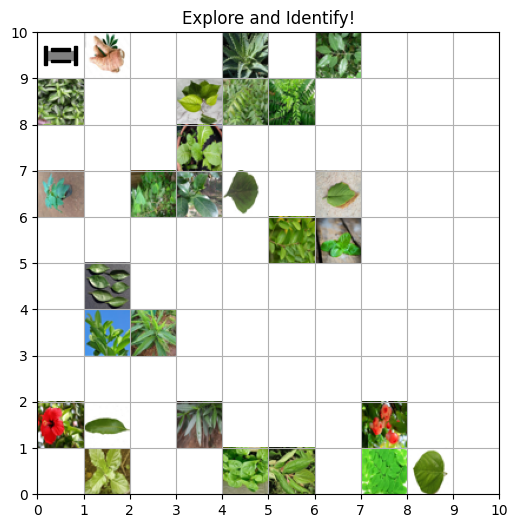

In [ ]:
env = DronePlantEnv()
env.render()

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.utils import get_schedule_fn # Import get_schedule_fn


# Create a wrapped version of your environment
def make_env():
    env = DronePlantEnv(
        plant_folder='/content/drive/MyDrive/plants',
        model_path='/content/drive/MyDrive/model1.h5',
        grid_size=10
    )
    return Monitor(env)

# Define a custom CNN feature extractor
class CustomCNN(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 256):
        super(CustomCNN, self).__init__(observation_space, features_dim)
        n_channels = observation_space.shape[2]

        self.cnn = nn.Sequential(
            nn.Conv2d(n_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
        )

        # Compute shape by doing one forward pass
        with th.no_grad():
            n_flatten = self.cnn(th.as_tensor(observation_space.sample()[None]).permute(0, 3, 1, 2).float()).shape[1]

        self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.ReLU())

    def forward(self, observations: th.Tensor) -> th.Tensor:
        observations = observations.permute(0, 3, 1, 2)
        return self.linear(self.cnn(observations))



def linear_schedule(initial_value: float):
    return get_schedule_fn(initial_value)


train_env = DummyVecEnv([make_env])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True,
                   clip_obs=10.0, clip_reward=10.0)
eval_env = DummyVecEnv([make_env])
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward= True,
                        clip_obs=10.0, clip_reward=10.0)

# Copy normalization stats from train → eval
eval_env.obs_rms = train_env.obs_rms
eval_env.ret_rms = train_env.ret_rms

# Freeze running stats in eval
eval_env.training = False

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./ppo_best_model",
    log_path="./logs/",
    eval_freq=30000,
    deterministic=True,
    render=False
)

device = 'cuda' if th.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = PPO(
    policy="CnnPolicy",
    env=train_env,
    learning_rate=linear_schedule(5e-4),
    n_steps=512,
    batch_size=64,
    n_epochs=8,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=linear_schedule(0.3),
    ent_coef=0.05,
    vf_coef=0.5,
    max_grad_norm=1.0,
    verbose=1,
    normalize_advantage=True,
    tensorboard_log="./ppo_plant_tensorboard/",
    device=device,
    policy_kwargs=dict(
        features_extractor_class=CustomCNN,
        features_extractor_kwargs=dict(features_dim=256),
        normalize_images=False
    )
)

# Train the model
model.learn(total_timesteps=300000, callback=eval_callback)

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Define the make_env function again for this cell's scope
def make_env():
    return DronePlantEnv(
        plant_folder='/content/drive/MyDrive/plants',
        model_path='/content/drive/MyDrive/model1.h5',
        grid_size=10
    )

# Load the best model
# Ensure the directory exists and contains the saved model files
try:
    best_model = PPO.load("./ppo_best_model/best_model.zip")
    print("Best model loaded successfully.")
except Exception as e:
    print(f"Error loading best model: {e}")
    print("Please ensure that the training ran successfully and the best_model.zip file exists in ./ppo_best_model")

Best model loaded successfully.


In [ ]:
# Evaluate performance of best model over 10 episodes

import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Define the make_env function again for this cell's scope
def make_env():
    return DronePlantEnv(
        plant_folder='/content/drive/MyDrive/plants',
        model_path='/content/drive/MyDrive/model1.h5',
        grid_size=10
    )

# Load the best model
# Ensure the directory exists and contains the saved model files
try:
    best_model = PPO.load("./ppo_best_model/best_model.zip")
    print("Best model loaded successfully.")
except Exception as e:
    print(f"Error loading best model: {e}")
    print("Please ensure that the training ran successfully and the best_model.zip file exists in ./ppo_best_model")

# Evaluate the best model over 10 episodes
num_eval_episodes = 10
cumulative_rewards = []

if 'eval_env' not in locals():
    print("Creating eval_env as it was not found in the current scope.")
    # This part would be needed if running this cell without the training cell first
    # eval_env = DummyVecEnv([make_env])
    # eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward= False,
    #                         clip_obs=10.0, clip_reward=10.0)
    # print("Please ensure the training cell was run to properly normalize eval_env.")
    pass # Assuming eval_env is available

if 'best_model' in locals() and best_model is not None and 'eval_env' in locals():
  print(f"\nEvaluating the best model over {num_eval_episodes} episodes...")

  # Set evaluation mode for the eval environment
  eval_env.training = False
  eval_env.norm_reward = False


  for episode in range(num_eval_episodes):
    obs = eval_env.reset()
    done = False
    total_reward = 0
    while not done:
      action, _states = best_model.predict(obs, deterministic=True)
      obs, reward, done, info = eval_env.step(action)
      total_reward += reward[0]
    cumulative_rewards.append(total_reward)
    print(f"Episode {episode+1}: Total Reward = {total_reward:.2f}")

  average_reward = np.mean(cumulative_rewards)
  print(f"\nAverage reward over {num_eval_episodes} episodes: {average_reward:.2f}")

  # Plot the rewards per episode
  plt.figure(figsize=(8, 5))
  plt.plot(range(1, num_eval_episodes + 1), cumulative_rewards, marker='o')
  plt.title('Total Reward per Evaluation Episode')
  plt.xlabel('Episode')
  plt.ylabel('Total Reward')
  plt.grid(True)
  plt.show()

else:
  print("Best model or eval_env not loaded. Cannot perform evaluation.")
  print("Please check the previous cell for errors during model loading or ensure the training cell was run.")

In [ ]:
# Simulation of the behaviour of the drone over 10episodes in one gif making sure predictions and confidence score are displayed on top of the grid

import matplotlib.pyplot as plt
import numpy as np
import imageio
import types

num_simulation_episodes = 10
gif_frames = []

if 'best_model' in locals() and best_model is not None:
    print(f"\nSimulating the best model over {num_simulation_episodes} episodes for GIF creation...")
    # Create a single environment instance for rendering
    sim_env = make_env()

    for episode in range(num_simulation_episodes):
        obs, _ = sim_env.reset() # Reset returns observation and info
        done = False
        total_reward = 0

        while not done:
            def render_frame_with_prediction(self):
                fig, ax = plt.subplots(figsize=(6, 6))
                ax.set_xlim(0, self.grid_size[0])
                ax.set_ylim(0, self.grid_size[1])
                ax.set_xticks(np.arange(self.grid_size[0] + 1))
                ax.set_yticks(np.arange(self.grid_size[1] + 1))
                ax.grid(True)

                for (x, y) in self.visited:
                    rect = patches.Rectangle((x, self.grid_size[1] - 1 - y), 1, 1,
                                             linewidth=1, edgecolor='none', facecolor='lightgreen', alpha=0.4)
                    ax.add_patch(rect)

                for cls, (px, py) in self.plant_positions.items():
                    img = self.plant_images[cls]
                    img = img.convert("RGB")
                    ax.imshow(img, extent=[px, px + 1, self.grid_size[1] - 1 - py, self.grid_size[1] - py])

                dx, dy = self.drone_pos
                drone_center_x = dx + 0.5
                drone_center_y = self.grid_size[1] - 1 - dy + 0.5

                drone_body = patches.Rectangle((drone_center_x - 0.3, drone_center_y - 0.1), 0.6, 0.2, color='gray')
                ax.add_patch(drone_body)

                arm_length = 0.4
                arm_width = 0.05
                ax.add_patch(patches.Rectangle((drone_center_x - arm_length/2, drone_center_y + 0.1),
                                               arm_length, arm_width, color='black'))
                ax.add_patch(patches.Rectangle((drone_center_x - arm_length/2, drone_center_y - 0.1 - arm_width),
                                               arm_length, arm_width, color='black'))
                ax.add_patch(patches.Rectangle((drone_center_x - 0.3 - arm_width, drone_center_y - arm_length/2),
                                               arm_width, arm_length, color='black'))
                ax.add_patch(patches.Rectangle((drone_center_x + 0.3, drone_center_y - arm_length/2),
                                               arm_width, arm_length, color='black'))

                if self.last_prediction:
                    cls, conf = self.last_prediction
                    ax.set_title(f"Prediction: {cls} ({conf:.2f})", fontsize=12)

                fig.canvas.draw()
                image_rgba = np.asarray(fig.canvas.buffer_rgba())
                plt.close(fig)
                return image_rgba

            # Temporarily add the render_frame_with_prediction method to the instance
            sim_env.render_frame_with_prediction = types.MethodType(render_frame_with_prediction, sim_env)

            # Capture the current frame
            frame = sim_env.render_frame_with_prediction()
            gif_frames.append(frame)

            # Take the action using the loaded model
            action, _states = best_model.predict(np.array([obs]), deterministic=True) # Predict expects batch input
            action = action[0] # Get the single action from the batch

            # Step the environment
            obs, reward, done, truncated, info = sim_env.step(action)
            total_reward += reward

            # Handle episode end
            if done or truncated:
                 # Capture the final frame
                frame = sim_env.render_frame_with_prediction()
                gif_frames.append(frame)
                print(f"Simulation Episode {episode+1} finished with total reward: {total_reward:.2f}")
                break

    # Save the frames as a GIF
    if gif_frames:
        gif_path = "./drone_simulation.gif"
        imageio.mimsave(gif_path, gif_frames, duration=0.2) # Adjust duration as needed
        print(f"\nSimulation GIF saved to {gif_path}")
    else:
        print("\nNo frames were captured for the GIF.")

else:
    print("Best model not loaded. Cannot perform simulation for GIF.")
    print("Please check the previous cells for errors during model loading.")